# Bounded-admittance inequality bound in the scattered-voltage basis

Implementation of Section *Bounded-Admittance Inequality Formulation* of the companion write-up (`dolphindes-AToM/main.tex`,
`sec:boundedAdmittance`) in the scattered-voltage variable $x = V_\mathrm{sca} = -Z_0 I$ (`sec:Vsca`, `VscatBound.ipynb`),
Cholesky-whitened basis ($\hat Z_\rho = Z_s \mathbf 1$, hats dropped).

With $u = V - Z_0 I = V + x$ and $\theta_i = Z_s \bar u_i i_i$, a design with density $\varsigma_i\in[0,1]$, $Z_s i_i = \varsigma_i u_i$, satisfies
$$
\operatorname{Im}\theta_i = 0,\qquad \operatorname{Re}\theta_i \ge 0,\qquad \operatorname{Re}\theta_i \le |u_i|^2 .
$$
The pointwise set ($3N$ constraints) is **not** imposed. Instead, both constraint families are generated from violations of the current
dual solution, as in `dolphindes/cvxopt/gcd.py`, and refined in one loop:

* **Shared constraints (power conservation)** $\operatorname{Re}[I^H P'^H (V + x - Z_s I)] = 0$ in shared-projector form
  ($A_1 = 1 + Z_s^* W^H$, $A_2 = W$, $s_1 = -V/2$, $W = Z_0^{-1}$): refined by `run_gcd` (max-violation and min-eigenvalue projectors,
  merging of the oldest ones).
* **Material density constraints** as general constraints. Each one is a weighted sum
  $$
  g(x) = \sum_i a_i \operatorname{Re}\theta_i + b_i\left(|u_i|^2 - \operatorname{Re}\theta_i\right) + c_i \operatorname{Im}\theta_i ,
  $$
  an equality ($a=b=0$) or an inequality $g\ge 0$ ($a, b \ge 0$, $c = 0$). New weights are the pointwise violations at $x^\star$:
  $c_i = \operatorname{Im}\theta_i$, $a_i = \max(0, -\operatorname{Re}\theta_i)$, $b_i = \max(0, \operatorname{Re}\theta_i - |u_i|^2)$, so every new
  constraint is violated at $x^\star$ (the GCD max-violation rule). When there are too many, the oldest of each kind are merged into one,
  weighted by their multipliers, which leaves the Lagrangian unchanged.

**Inequalities.** dolphindes has only equality general constraints. With $\mathcal L = f + \sum_j \lambda_j g_j$, an inequality $g_j\ge 0$ needs
$\lambda_j \ge 0$. After each solve, inequality constraints with $\lambda_j<0$ are dropped and the dual is re-solved (active set). Dual
feasibility after a drop is restored along the global real-power projector $P' = \mathbf 1$, for which
$\operatorname{Sym}(A_1A_2) = W^H\operatorname{Re}(Z_\mathrm{tot})W \succ 0$. Every reported value therefore has all inequality multipliers
$\ge 0$ and a PSD Lagrangian, and is a valid bound.

**Validity class.** Local power conservation holds only for binary designs (on an intermediate density $V + x - Z_s I = (1-\varsigma)u \ne 0$),
so the combined bound is over binary structures $\varsigma\in\{0,1\}$ in the whitened basis.

In [1]:
import contextlib
import io
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters
from dolphindes.cvxopt.gcd import GCDHyperparameters

geometry = "dipole"   # "dipole" or "patch21ka1"

mu_0 = 4e-7 * np.pi
omega = 2 * np.pi * 2.45e9
E0 = 1e3
copper_conductivity = 5.96e7
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity))
Zs = (1 + 1j) / (copper_conductivity * delta)

Lmat = np.loadtxt(f"Lmat_{geometry}.txt", delimiter=',')
Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return 0.5 * (M + M.conj().T)

def Mchol(M):
    return Msym(LcholInv.conj().T @ M @ LcholInv)

R0 = Mchol(np.loadtxt(f"R0_{geometry}.txt", delimiter=','))
X0 = Mchol(np.loadtxt(f"X0_{geometry}.txt", delimiter=','))
Vinc = LcholInv.conj().T @ (E0 * np.loadtxt(f"V_{geometry}.txt", delimiter=',').astype(complex))
Ndes = len(Vinc)
Z0 = R0 + 1j * X0
Ztot = Z0 + Zs * np.eye(Ndes)
W = np.linalg.inv(Z0)
WH = W.conj().T

def evalObjI(I):
    return 0.5 * np.real(I.conj() @ R0 @ I)

def VtoI(x):
    return -W @ x

def realizedObj(rho):
    '''Radiated power of the structure with density rho (whitened basis): (Zs + diag(rho) Z0) I = diag(rho) V.'''
    S = np.diag(rho.astype(complex))
    return evalObjI(np.linalg.solve(Zs * np.eye(Ndes) + S @ Z0, S @ Vinc))

Pfull = evalObjI(np.linalg.solve(Ztot, Vinc))
print(f"{geometry}: N = {Ndes}, Zs = {Zs:.3e}, cond(Z0) = {np.linalg.cond(Z0):.2e}, full plate P = {Pfull:.8e} W")

dipole: N = 195, Zs = 1.274e-02+1.274e-02j, cond(Z0) = 1.75e+04, full plate P = 1.01082134e+01 W


## Objective and shared constraints

As in `VscatBound.ipynb`: $A_0 = -\tfrac12 W^H R_0 W$, $s_0 = 0$, $c_0 = 0$, projectors $P' = \operatorname{diag}(\bar p)$, global $p = 1$ (real power)
and $p = -\mathrm j$ (reactive power).

In [2]:
A0 = -0.5 * Msym(WH @ R0 @ W)
s0 = np.zeros(Ndes, dtype=complex)
A1 = np.eye(Ndes) + np.conj(Zs) * WH
A2 = W
s1 = -0.5 * Vinc
Pglobal = np.column_stack([np.ones(Ndes), 1j * np.ones(Ndes)]).astype(complex)   # P' = conj(p), p = 1 and -j

def projRes(x, pp):
    '''Shared constraint Re(-x^H A1 P' A2 x + 2 x^H A2^H P'^H s1) for P' = diag(pp).'''
    return np.real(-x.conj() @ A1 @ (pp * (A2 @ x)) + 2 * x.conj() @ (A2.conj().T @ (np.conj(pp) * s1)))

## Material density constraints

In current form $\operatorname{Re}(-I^H B I + 2 I^H t + c)$, with $G = \operatorname{diag}(a - b - \mathrm j c)$ and $D_b = \operatorname{diag}(b)$,
$$
B = \operatorname{Sym}(Z_s Z_0^H G) - Z_0^H D_b Z_0,\qquad t = \tfrac12 Z_s^* \bar G V - Z_0^H D_b V,\qquad c = V^H D_b V .
$$
dolphindes evaluates general constraints as $\operatorname{Re}(-x^H A_2^H B_j A_2 x + 2x^H A_2^H s_{2j} + c_{2j})$ and $A_2 x = -I$, so
$B_j = B$, $s_{2j} = -t$, $c_{2j} = c$. Each constraint is normalized by $\|B\|_2$.

In [3]:
def thetaU(x):
    '''theta_i = Zs conj(u_i) i_i and |u_i|^2, u = V + x.'''
    I = VtoI(x)
    u = Vinc + x
    return Zs * np.conj(u) * I, np.abs(u) ** 2

def conValue(con, x):
    th, U2 = thetaU(x)
    return np.sum(con['a'] * th.real + con['b'] * (U2 - th.real) + con['c'] * th.imag)

def conMats(con):
    g = con['a'] - con['b'] - 1j * con['c']
    B = Msym(Zs * Z0.conj().T * g[None, :]) - (Z0.conj().T * con['b'][None, :]) @ Z0
    t = np.conj(Zs) * np.conj(g) * Vinc / 2 - Z0.conj().T @ (con['b'] * Vinc)
    c = np.real(np.sum(con['b'] * np.abs(Vinc) ** 2))
    return B, -t, c

def newCon(a=None, b=None, c=None, kind='ineq'):
    z = np.zeros(Ndes)
    con = dict(kind=kind, a=z if a is None else a, b=z if b is None else b, c=z if c is None else c)
    scale = np.linalg.norm(conMats(con)[0], 2)
    for k in 'abc':
        con[k] = con[k] / scale
    return con

# check: general form vs. direct evaluation at a random point
rng = np.random.default_rng(0)
xr = rng.standard_normal(Ndes) + 1j * rng.standard_normal(Ndes)
con = newCon(rng.random(Ndes), rng.random(Ndes), rng.standard_normal(Ndes))
B, s, c = conMats(con)
print(f"direct {conValue(con, xr):.12e}, general form {np.real(-xr.conj() @ WH @ B @ W @ xr + 2 * xr.conj() @ WH @ s + c):.12e}")

direct 6.158519659730e-07, general form 6.158519659632e-07


## Solver pieces

* `build`: QCQP with the current projectors and general constraints.
* `restore`: dual feasibility along the real-power projector combination $\sum_k\alpha_k P'_k = \mathbf 1$.
* `solveSigned`: dual solve with the active-set rule $\lambda_j \ge 0$ for inequalities.
* `merge`: oldest constraints of each kind merged into one, weighted by their multipliers.

In [4]:
opt_params = OptimizationHyperparameters(opttol=1e-6, gradConverge=True, min_inner_iter=10, max_restart=10,
                                         penalty_ratio=1e-2, penalty_reduction=0.1, break_iter_period=5, verbose=0)
gcd_params = GCDHyperparameters(max_proj_cstrt_num=30, max_gcd_iter_num=8, gcd_iter_period=4, gcd_tol=1e-4,
                                orthonormalize=True, ortho_metric='euclidean', method='newton', opt_params=opt_params)

def build(Pdata, cons):
    mats = [conMats(k) for k in cons]
    Plist = [sp.diags(Pdata[:, j]) for j in range(Pdata.shape[1])]
    kw = dict(B_j=[m[0] for m in mats], s_2j=[m[1] for m in mats], c_2j=[m[2] for m in mats]) if cons else {}
    return DenseSharedProjQCQP(A0, s0, 0.0, A1, s1, Plist, A2=A2, verbose=0, **kw)

def restore(Q, lags):
    if Q.is_dual_feasible(lags):
        return lags
    Pd = Q.Proj.get_Pdata_column_stack()
    M = np.vstack([Pd.real, Pd.imag])
    rhs = np.concatenate([np.ones(Ndes), np.zeros(Ndes)])
    alpha = np.linalg.lstsq(M, rhs, rcond=None)[0]
    if np.linalg.norm(M @ alpha - rhs) > 1e-8 * np.sqrt(Ndes):
        raise RuntimeError("real power projector is not in the projector span")
    t = 1e-3
    while True:
        l = lags.copy()
        l[:Q.n_proj_constr] += t * alpha
        if Q.is_dual_feasible(l):
            return l
        t *= 2

def solveSigned(Pdata, cons, lags):
    nDropped = 0
    while True:
        Q = build(Pdata, cons)
        lags = restore(Q, lags)
        Q.solve_current_dual_problem(method='newton', init_lags=lags, opt_params=opt_params)
        lg = Q.current_lags[Q.n_proj_constr:]
        bad = [j for j, k in enumerate(cons) if k['kind'] == 'ineq' and lg[j] < 0]
        if not bad:
            return Q, cons, nDropped
        keep = [j for j in range(len(cons)) if j not in bad]
        nDropped += len(bad)
        cons = [cons[j] for j in keep]
        lags = np.concatenate([Q.current_lags[:Q.n_proj_constr], lg[keep]])

def merge(cons, lg, maxPerKind):
    out, outLags = [], []
    for kind in ['eq', 'ineq']:
        idx = [j for j, k in enumerate(cons) if k['kind'] == kind]
        if len(idx) > maxPerKind:
            m = idx[:len(idx) - maxPerKind + 1]
            out.append(dict(kind=kind, **{k: sum(lg[j] * cons[j][k] for j in m) for k in 'abc'}))
            outLags.append(1.0)
            idx = idx[len(m):]
        out += [cons[j] for j in idx]
        outLags += [lg[j] for j in idx]
    return out, np.array(outLags)

## Reference bounds: global, and global + GCD (no density constraints)

In [5]:
Q = build(Pglobal, [])
Q.solve_current_dual_problem(method='newton', init_lags=np.array([1., 0.]), opt_params=opt_params)
globalBound = Q.current_dual
with contextlib.redirect_stdout(io.StringIO()):
    Q.run_gcd(gcd_params=gcd_params)
gcdBound, gcdX = Q.current_dual, Q.current_xstar.copy()
print(f"global bound {globalBound:.8e} W, GCD bound {gcdBound:.8e} W, full plate {Pfull:.8e} W")

global bound 1.01209328e+01 W, GCD bound 1.01107973e+01 W, full plate 1.01082134e+01 W


## Combined loop

Each round: add the three violation-weighted density constraints (equality, passive, upper) at the current $x^\star$, merge, run GCD on the
shared constraints, then enforce $\lambda\ge 0$ on the inequalities.

In [6]:
nOuter = 40
maxPerKind = 6
Pdata, lags = Q.Proj.get_Pdata_column_stack(), Q.current_lags.copy()
cons = []
hist = []
t0 = time.time()
for outer in range(nOuter):
    th, U2 = thetaU(Q.current_xstar)
    weights = [dict(c=th.imag, kind='eq'), dict(a=np.maximum(0, -th.real)), dict(b=np.maximum(0, th.real - U2))]
    add = [newCon(**w) for w in weights if any(np.any(v != 0) for k, v in w.items() if k != 'kind')]   # skip all-zero weights
    cons = cons + add
    lags = np.concatenate([lags, np.zeros(len(add))])   # previous Lagrangian: dual feasible
    cons, lg = merge(cons, lags[Pdata.shape[1]:], maxPerKind)
    lags = np.concatenate([lags[:Pdata.shape[1]], lg])

    Q = build(Pdata, cons)
    Q.current_lags = restore(Q, lags)
    with contextlib.redirect_stdout(io.StringIO()):
        Q.run_gcd(gcd_params=gcd_params)
    Q, cons, nDropped = solveSigned(Q.Proj.get_Pdata_column_stack(), cons, Q.current_lags.copy())
    Pdata, lags = Q.Proj.get_Pdata_column_stack(), Q.current_lags.copy()

    th, U2 = thetaU(Q.current_xstar)
    hist.append(dict(bound=Q.current_dual, nGen=len(cons), nDropped=nDropped,
                     imRel=np.linalg.norm(th.imag) / np.linalg.norm(th),
                     passViol=np.linalg.norm(np.maximum(0, -th.real)) / np.linalg.norm(th),
                     upViol=np.linalg.norm(np.maximum(0, th.real - U2)) / np.linalg.norm(th)))
    if outer % 5 == 4 or outer == 0:
        print(f"round {outer:>2}: bound {Q.current_dual:.8e} W, {len(cons)} general ({nDropped} dropped), "
              f"rel. violations Im {hist[-1]['imRel']:.2e}, passive {hist[-1]['passViol']:.2e}, upper {hist[-1]['upViol']:.2e}")
print(f"total {time.time() - t0:.0f}s")

round  0: bound 1.01095790e+01 W, 2 general (0 dropped), rel. violations Im 6.85e-01, passive 5.13e-01, upper 0.00e+00


round  4: bound 1.01088032e+01 W, 10 general (0 dropped), rel. violations Im 5.99e-01, passive 5.70e-01, upper 0.00e+00


round  9: bound 1.01085592e+01 W, 10 general (2 dropped), rel. violations Im 6.19e-01, passive 5.44e-01, upper 0.00e+00


round 14: bound 1.01084381e+01 W, 10 general (2 dropped), rel. violations Im 7.06e-01, passive 4.80e-01, upper 0.00e+00


round 19: bound 1.01083706e+01 W, 9 general (3 dropped), rel. violations Im 6.16e-01, passive 5.02e-01, upper 0.00e+00


round 24: bound 1.01083358e+01 W, 8 general (2 dropped), rel. violations Im 3.29e-01, passive 6.41e-01, upper 0.00e+00


round 29: bound 1.01083208e+01 W, 7 general (2 dropped), rel. violations Im 5.80e-01, passive 5.56e-01, upper 0.00e+00


round 34: bound 1.01083085e+01 W, 8 general (2 dropped), rel. violations Im 5.41e-01, passive 5.13e-01, upper 1.69e-03


round 39: bound 1.01082999e+01 W, 8 general (2 dropped), rel. violations Im 4.42e-01, passive 5.53e-01, upper 2.02e-03
total 89s


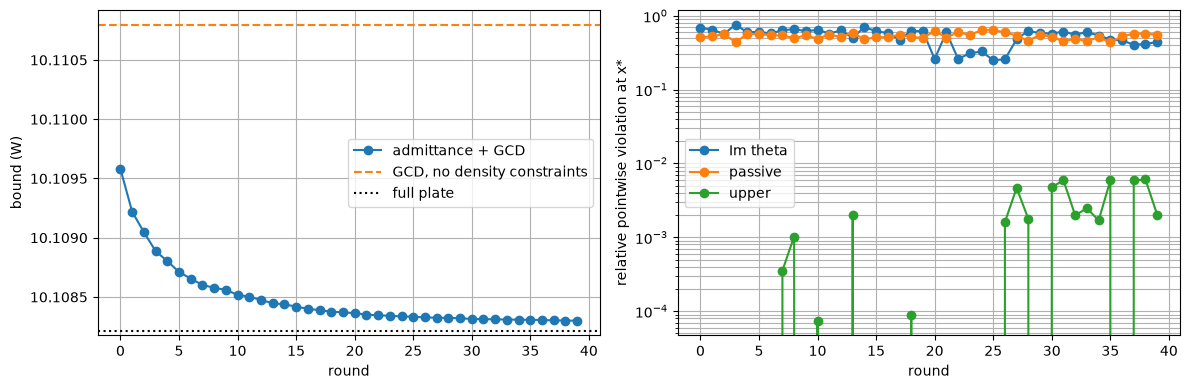

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([h['bound'] for h in hist], 'o-', label='admittance + GCD')
axes[0].axhline(gcdBound, c='C1', ls='--', label='GCD, no density constraints')
axes[0].axhline(Pfull, c='k', ls=':', label='full plate')
axes[0].set_xlabel('round'); axes[0].set_ylabel('bound (W)'); axes[0].legend(); axes[0].grid(True)
for key, lab in [('imRel', 'Im theta'), ('passViol', 'passive'), ('upViol', 'upper')]:
    axes[1].semilogy([h[key] for h in hist], 'o-', label=lab)
axes[1].set_xlabel('round'); axes[1].set_ylabel('relative pointwise violation at x*'); axes[1].legend(); axes[1].grid(True, which='both')
plt.tight_layout(); plt.show()

## Validity

Every constraint in the final problem must hold for every binary design, the inequality multipliers must be non-negative, the Lagrangian
must be PSD, and the bound must not fall below the full plate (itself a binary design). Residuals are normalized by the magnitude of the
terms they cancel ($|Z_0|$-scale).

In [8]:
lgGen = Q.current_lags[Q.n_proj_constr:]
print(f"inequality multipliers >= 0: {all(l >= 0 for l, k in zip(lgGen, cons) if k['kind'] == 'ineq')}, "
      f"min eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(Q._get_total_A(Q.current_lags)))):.3e}")
print(f"bound - full plate = {Q.current_dual - Pfull:.3e} W (must be >= 0)")

Pd = Q.Proj.get_Pdata_column_stack()
worst = dict(eq=0.0, ineq=0.0, proj=0.0)
for _ in range(100):
    rho = (rng.random(Ndes) < rng.uniform(0.1, 1)).astype(float)
    S = np.diag(rho.astype(complex))
    I = np.linalg.solve(Zs * np.eye(Ndes) + S @ Z0, S @ Vinc)
    x = -Z0 @ I
    scale = np.abs(I.conj() @ x) + 1e-300
    for k in cons:
        v = conValue(k, x)
        if k['kind'] == 'eq':
            worst['eq'] = max(worst['eq'], abs(v) / scale)
        else:
            worst['ineq'] = min(worst['ineq'], v / scale)
    worst['proj'] = max(worst['proj'], max(abs(projRes(x, Pd[:, j])) for j in range(Pd.shape[1])) / scale)
print(f"100 random binary designs: max |equality| {worst['eq']:.2e}, min inequality {worst['ineq']:.2e} (>= 0 up to round-off), "
      f"max |shared| {worst['proj']:.2e}")

inequality multipliers >= 0: True, min eigenvalue of A: 1.185e-06
bound - full plate = 8.645e-05 W (must be >= 0)


100 random binary designs: max |equality| 1.77e-14, min inequality 0.00e+00 (>= 0 up to round-off), max |shared| 2.72e-11


## Design readout

* From the dual current: $\varsigma_i = \operatorname{Re}\theta_i / |u_i|^2$, clipped to $[0,1]$, and a threshold sweep.
* From the multipliers (the readout proposed in the write-up): the effective pointwise multipliers are
  $\lambda_i^- = \sum_j \lambda_j a_{j,i}$ (passive) and $\lambda_i^+ = \sum_j \lambda_j b_{j,i}$ (upper); material where $\lambda_i^+ > \lambda_i^-$.

varsigma in [-2.232, 1.292], fraction in [0,1]: 0.59
#DOF with lambda+ > 0: 0, with lambda- > 0: 180, with both: 0
realized: clipped varsigma 1.037344e-06 W, best threshold 2.561110e-07 W (t = 0.05), multiplier readout 0.000000e+00 W (0/195 material)
bound 1.01082999e+01 W, full plate 1.01082134e+01 W


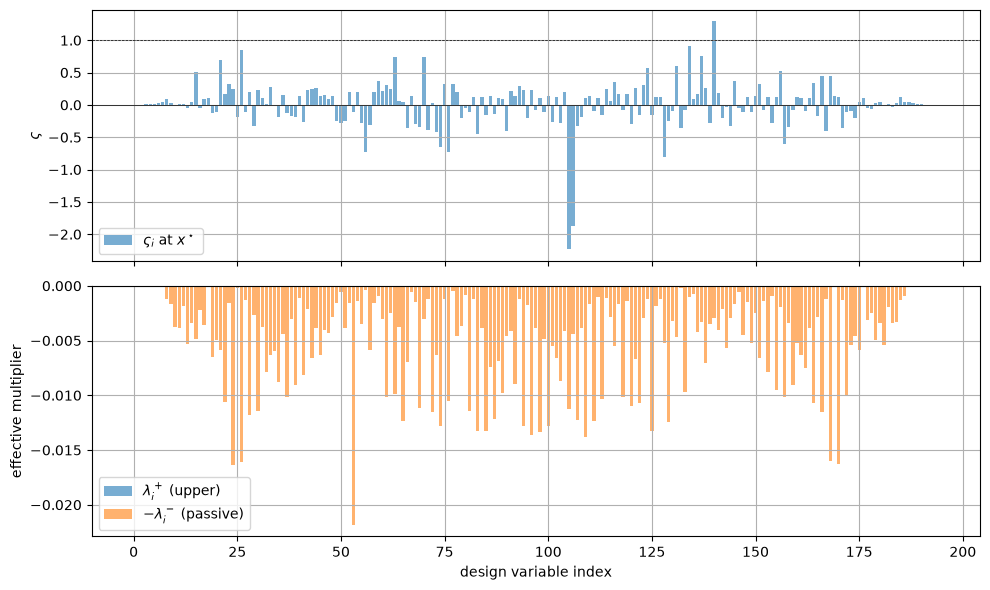

In [9]:
xs = Q.current_xstar
th, U2 = thetaU(xs)
vs = th.real / U2
lamMinus = sum(l * k['a'] for l, k in zip(lgGen, cons) if k['kind'] == 'ineq')
lamPlus = sum(l * k['b'] for l, k in zip(lgGen, cons) if k['kind'] == 'ineq')
rhoMult = (lamPlus > lamMinus).astype(float)

ths = np.linspace(0.05, 0.95, 19)
Pthr = np.array([realizedObj((vs > t).astype(float)) for t in ths])
print(f"varsigma in [{vs.min():.3f}, {vs.max():.3f}], fraction in [0,1]: {np.mean((vs >= 0) & (vs <= 1)):.2f}")
print(f"#DOF with lambda+ > 0: {np.sum(lamPlus > 0)}, with lambda- > 0: {np.sum(lamMinus > 0)}, with both: {np.sum((lamPlus > 0) & (lamMinus > 0))}")
print(f"realized: clipped varsigma {realizedObj(np.clip(vs, 0, 1)):.6e} W, best threshold {Pthr.max():.6e} W (t = {ths[Pthr.argmax()]:.2f}), "
      f"multiplier readout {realizedObj(rhoMult):.6e} W ({int(rhoMult.sum())}/{Ndes} material)")
print(f"bound {Q.current_dual:.8e} W, full plate {Pfull:.8e} W")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].bar(np.arange(Ndes), vs, alpha=0.6, label=r'$\varsigma_i$ at $x^\star$')
axes[0].axhline(0, c='k', lw=0.5); axes[0].axhline(1, c='k', lw=0.5, ls='--')
axes[0].set_ylabel(r'$\varsigma$'); axes[0].legend(); axes[0].grid(True)
axes[1].bar(np.arange(Ndes), lamPlus, alpha=0.6, label=r'$\lambda_i^+$ (upper)')
axes[1].bar(np.arange(Ndes), -lamMinus, alpha=0.6, label=r'$-\lambda_i^-$ (passive)')
axes[1].set_xlabel('design variable index'); axes[1].set_ylabel('effective multiplier'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

## Observations (dipole, 40 rounds)

1. **The formulation is valid.** All inequality multipliers stay $\ge 0$, the Lagrangian is PSD (min eigenvalue $1.2\cdot10^{-6}$),
   every generated constraint holds on 100 random binary designs to round-off ($10^{-14}$ equalities, $10^{-11}$ shared, inequalities $\ge 0$),
   and the bound never falls below the full plate.
2. **The density constraints tighten the bound substantially.** Global $10.120933$ W, GCD $10.110797$ W, admittance + GCD $10.108300$ W,
   against the full plate $10.108213$ W, which is optimal for this structure. The gap to the full plate drops from $2.58\cdot10^{-3}$ W (GCD) to
   $8.6\cdot10^{-5}$ W, 97% closed, and is still decreasing slowly (about $10^{-6}$ W per round). Each round costs ~2 s.
3. **Only the passive and Im constraints matter.** The dual current essentially never exceeds the upper bound $\operatorname{Re}\theta_i\le|u_i|^2$.
   What the relaxation exploits is local gain ($\operatorname{Re}\theta_i<0$) and a complex density ($\operatorname{Im}\theta_i\ne0$), which is
   exactly the non-physical behaviour the write-up attributes to aggregated projectors. The active set drops 2–3 inequality constraints per round.
4. **The pointwise violations at $x^\star$ do not decrease** (about 50% relative for both Im and passive). The bound converges toward the
   full plate, but the dual current does not become realizable, consistent with the near-null directions of the Lagrangian at the PSD boundary.
5. **The multiplier readout fails with aggregated constraints.** $\lambda^+_i = 0$ everywhere and $\lambda^-_i>0$ on 180 of 195 DOFs, so the readout
   says "vacuum everywhere" (0 W) although the optimum is the full plate. With aggregated constraints, complementary slackness holds only for
   the weighted sum, $\sum_i a_i\operatorname{Re}\theta_i = 0$, not for each DOF, so $\lambda^-_i>0$ does not imply $\operatorname{Re}\theta_i = 0$.
   The write-up's readout needs the pointwise constraints, at least on the DOFs that carry the design. The $\varsigma$ readout from $x^\star$ fails
   as well ($10^{-6}$ W).

To switch geometry, set `geometry = "patch21ka1"` in the first code cell.
